## [1. Import Needed Modules](#import) ##
## [2. Resize and store all images into working directory](#resize) ##
## [3. Read in resized images and create a dataframe of image paths and class labels](#makedf) ##
## [4. Balance train_df using the balance function](#trim) ##
## [5. Create train, test and validation generators](#generators) ##
## [6. Create a function to show Training Image Samples](#show) ##
## [7. Create the Model](#model) ##
## [8. Create a custom Keras callback to continue or halt training](#callback) ##
## [9. Instantiate custom callback and create callbacks to control learning rate and early stopping](#callbacks) ##
## [10. Train the model](#train) ##
## [11. Define a function to plot the training data](#plot) ##
## [12. Make predictions on test set, create Confusion Matrix and Classification Report](#result) ##
## [13 Save the model](#save) ##


In [ ]:
!pip install numpy pandas matplotlib opencv-python seaborn scikit-learn tensorflow keras

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.3-py3-none-any

<a id="import"></a>
# <center>Import Need Modules</center>

In [ ]:
# Google Colab specific imports
from google.colab import drive
# Core libraries
import numpy as np
import pandas as pd
import os
import time
import shutil

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Visualization
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
sns.set_style('darkgrid')

# Machine Learning
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras

# Enable mixed precision for faster training on GPU
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('float32')
mixed_precision.set_global_policy(policy)
print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)
# Keras modules
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

# Check GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    print("GPU detected! Training will be fast.")
else:
    print("No GPU detected. Training will be slow.")

ModuleNotFoundError: No module named 'google.colab'

### The size of the images are very large. If you try to use the full image size training will take a very long time. Therefore you
### want to reduce the image size. However if you include resizing of images as part of training it requires each image to be repeatedly
### resized in each epoch. This also make the training times to be large. It is more efficient to resize all the images FIRST and save them.
### Then use these images for training.

<a id="resize"></a>
# <center>Resize all images and save to the working directory</center>

In [ ]:
# Ensure resized dataset exists — resizing moved to `augmented.ipynb`
start_time = time.time()
working_dir = '/content/cauliflower_training/'
img_height = 300
img_width = 300

# where augmented.ipynb writes the resized images
save_path = os.path.join(working_dir, 'cali')

if not os.path.isdir(save_path):
    print(f"Resized dataset not found at {save_path}.")
    print("Run `augmented.ipynb` preprocessing cell to create resized images, or copy your resized images to this path.")
else:
    total = 0
    classlist = sorted(os.listdir(save_path))
    for klass in classlist:
        classpath = os.path.join(save_path, klass)
        if not os.path.isdir(classpath):
            continue
        flist = os.listdir(classpath)
        print('found', len(flist), 'images for class', klass)
        total += len(flist)
    tr_duration = time.time() - start_time
    hours = tr_duration // 3600
    minutes = (tr_duration - (hours * 3600)) // 60
    seconds = tr_duration - ((hours * 3600) + (minutes * 60))
    msg = f'checked resized dataset in {minutes:4.1f} minutes, {seconds:4.2f} seconds'
    print(msg, flush=True)
    print('Total resized images found:', total)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
processing  Alternaria Leaf Spot  class
processing  Bacterial Soft Rot  class
processing  Black Rot  class
processing  Black Spot  class
processing  Downy Mildew  class
processing  Healthy  class
resizing elapsed time was 0.0 hours,  3.0 minutes, 36.45 seconds)


<a id="makedf"></a>
# <center>Read in resized images and create a dataframe of image paths and class labels</center>

In [ ]:
def make_df(save_path):
    classlist=os.listdir(save_path)
    filepaths=[]
    labels=[]
    for klass in classlist:
        classpath=os.path.join(save_path, klass)
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            filepaths.append(fpath)
            labels.append(klass)
    Fseries=pd.Series(filepaths, name='filepaths')
    Lseries=pd.Series(labels, name='labels')
    df=pd.concat([Fseries, Lseries], axis=1)
    train_df, dummy_df=train_test_split(df, train_size=.8, shuffle=True, random_state=123, stratify=df['labels'])
    valid_df, test_df=train_test_split(dummy_df,train_size=.5, shuffle=True, random_state=123, stratify=dummy_df['labels'])
    print('train_df lenght: ', len(train_df), '  test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))
    # get the number of classes and the images count for each class in train_df
    classes=sorted(list(train_df['labels'].unique()))
    class_count = len(classes)
    print('The number of classes in the dataset is: ', class_count)
    groups=train_df.groupby('labels')
    print('{0:^30s} {1:^13s}'.format('CLASS', 'IMAGE COUNT'))
    countlist=[]
    classlist=[]
    for label in sorted(list(train_df['labels'].unique())):
        group=groups.get_group(label)
        countlist.append(len(group))
        classlist.append(label)
        print('{0:^30s} {1:^13s}'.format(label, str(len(group))))

    # get the classes with the minimum and maximum number of train images
    max_value=np.max(countlist)
    max_index=countlist.index(max_value)
    max_class=classlist[max_index]
    min_value=np.min(countlist)
    min_index=countlist.index(min_value)
    min_class=classlist[min_index]
    print(max_class, ' has the most images= ',max_value, ' ', min_class, ' has the least images= ', min_value)
    # lets get the average height and width of a sample of the train images
    ht=0
    wt=0
    # select 100 random samples of train_df
    train_df_sample=train_df.sample(n=100, random_state=123,axis=0)
    for i in range (len(train_df_sample)):
        fpath=train_df_sample['filepaths'].iloc[i]
        img=plt.imread(fpath)
        shape=img.shape
        ht += shape[0]
        wt += shape[1]
    print('average height= ', ht//100, ' average width= ', wt//100, 'aspect ratio= ', ht/wt)
    return train_df, test_df, valid_df, classes
train_df, test_df, valid_df, classes = make_df(save_path)
class_count=len(classes)

train_df lenght:  6725   test_df length:  841   valid_df length:  841
The number of classes in the dataset is:  6
            CLASS               IMAGE COUNT 
     Alternaria Leaf Spot          1206     
      Bacterial Soft Rot           1121     
          Black Rot                 640     
          Black Spot                201     
         Downy Mildew              1029     
           Healthy                 2528     
Healthy  has the most images=  2528   Black Spot  has the least images=  201
average height=  300  average width=  300 aspect ratio=  1.0


<a id="balance"></a>
# <center>Expand train_df by creating augmented images</center>


In [ ]:
# prefer cleaned augmented file if present
clean_csv = os.path.join(working_dir, 'train_augmented_clean.csv')
merged_csv = clean_csv if os.path.exists(clean_csv) else os.path.join(working_dir, 'train_augmented.csv')

if os.path.exists(merged_csv):
    print(f"Loading augmented merged dataset: {merged_csv}")
    train_df = pd.read_csv(merged_csv)
    # normalize column names if needed
    if 'filepaths' not in train_df.columns:
        cols = list(train_df.columns)
        if len(cols) >= 2:
            train_df = train_df.rename(columns={cols[0]: 'filepaths', cols[1]: 'labels'})
    if set(['filepaths', 'labels']).issubset(train_df.columns):
        train_df = train_df[['filepaths', 'labels']]
    print('Train set size after loading augmented data:', len(train_df))
else:
    print(f"{merged_csv} not found — using original `train_df` from make_df()")

Initial length of dataframe is  6725
Total Augmented images created=  0
Length of augmented dataframe is now  6725


<a id="generators"></a>
# <center>Create the train_gen, test_gen final_test_gen and valid_gen</center>

In [ ]:
batch_size=80 # We will use and EfficientetB3 model, with image size of (200, 250) this size should not cause resource error
trgen=ImageDataGenerator(horizontal_flip=True,rotation_range=20, width_shift_range=.2,
                                  height_shift_range=.2, zoom_range=.2 )
t_and_v_gen=ImageDataGenerator()
msg='{0:70s} for train generator'.format(' ')
print(msg, '\r', end='') # prints over on the same line
train_gen=trgen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size)
msg='{0:70s} for valid generator'.format(' ')
print(msg, '\r', end='') # prints over on the same line
valid_gen=t_and_v_gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=batch_size)
# for the test_gen we want to calculate the batch size and test steps such that batch_size X test_steps= number of samples in test set
# this insures that we go through all the sample in the test set exactly once.
length=len(test_df)
test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80],reverse=True)[0]
test_steps=int(length/test_batch_size)
msg='{0:70s} for test generator'.format(' ')
print(msg, '\r', end='') # prints over on the same line
test_gen=t_and_v_gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=test_batch_size)
# from the generator we can get information we will need later
classes=list(train_gen.class_indices.keys())
class_indices=list(train_gen.class_indices.values())
class_count=len(classes)
labels=test_gen.labels
print ( 'test batch size: ' ,test_batch_size, '  test steps: ', test_steps, ' number of classes : ', class_count)

Found 6724 validated image filenames belonging to 6 classes.
Found 841 validated image filenames belonging to 6 classes.
Found 841 validated image filenames belonging to 6 classes.
test batch size:  29   test steps:  29  number of classes :  6


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filepaths". These filename(s) will be ignored.
  warnings.warn(


<a id="show"></a>
# <center>Create a function to show example training images</center>

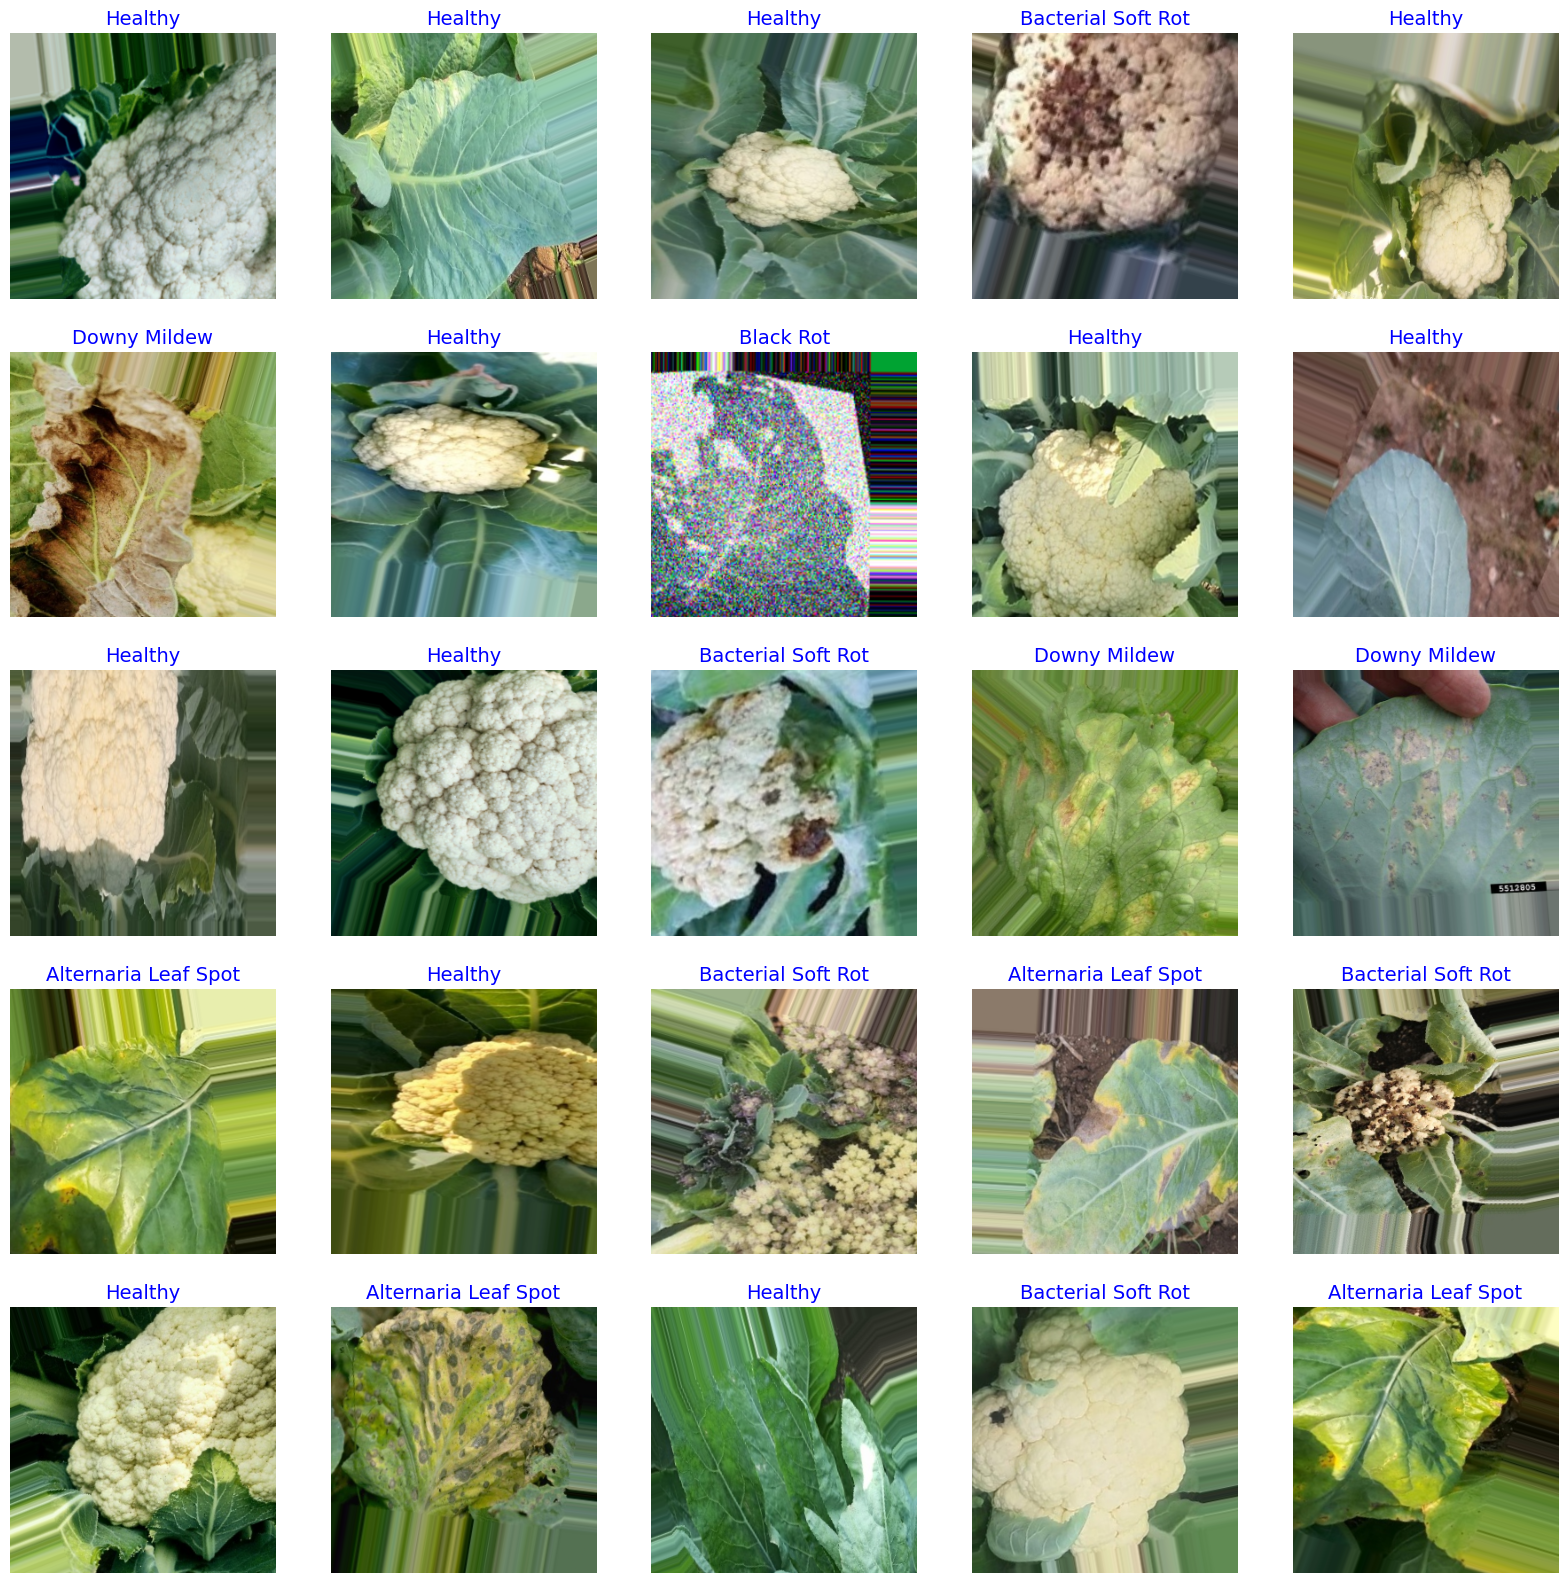

In [ ]:
def show_image_samples(gen ):
    t_dict=gen.class_indices
    classes=list(t_dict.keys())
    images,labels=next(gen) # get a sample batch from the generator
    plt.figure(figsize=(20, 20))
    length=len(labels)
    if length<25:   #show maximum of 25 images
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image=images[i] /255
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=14)
        plt.axis('off')
    plt.show()

show_image_samples(train_gen )

<a id="model"></a>
# <center>Create a model using transfer learning with EfficientNetB3</center>
### NOTE experts advise you make the base model initially not trainable. Then train for some number of epochs
### then fine tune model by making base model trainable and run more epochs
### I have found this to be WRONG!!!!
### Making the base model trainable from the outset leads to faster convegence and a lower validation loss
### for the same number of total epochs!

In [ ]:
img_shape = (img_size[0], img_size[1], 3)
model_name = 'EfficientNetB3'

# Create base model
base_model = tf.keras.applications.efficientnet.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable = True

# Build model
x = base_model.output
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)
x = Dense(256,
          kernel_regularizer=regularizers.l2(0.016),
          activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006),
          activation='relu')(x)
x = Dropout(rate=.4, seed=123)(x)

# Output layer MUST be float32 for mixed precision
output = Dense(class_count, activation='softmax', dtype='float32', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
lr = .001
model.compile(
    Adamax(learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,184,693 (42.67 MB)

 Trainable params: 11,094,318 (42.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

<a id="callback"></a>
# <center>Create a custom Keras callback to continue and optionally set LR or halt training</center>
The LR_ASK callback is a convenient callback that allows you to continue training for ask_epoch more epochs or to halt training.  
If you elect to continue training for more epochs you are given the option to retain the current learning rate (LR) or to  
enter a new value for the learning rate. The form of use is:  
ask=LR_ASK(model,epochs, ask_epoch) where:  
* model is a string which is the name of your compiled model
* epochs is an integer which is the number of epochs to run specified in model.fit
* ask_epoch is an integer. If ask_epoch is set to a value say 5 then the model will train for 5 epochs.  
  then the user is ask to enter H to halt training, or enter an inter value. For example if you enter 4  
  training will continue for 4 more epochs to epoch 9 then you will be queried again. Once you enter an  
  integer value you are prompted to press ENTER to continue training using the current learning rate  
  or to enter a new value for the learning rate.  
  
 At the end of training the model weights are set to the weights for the epoch that achieved the lowest validation loss

In [ ]:
class LR_ASK(keras.callbacks.Callback):
    def __init__ (self, model, epochs,  ask_epoch): # initialization of the callback
        super(LR_ASK, self).__init__()
        self.user_model=model  # Changed from self.model to self.user_model
        self.ask_epoch=ask_epoch
        self.epochs=epochs
        self.ask=True # if True query the user on a specified epoch
        self.lowest_vloss=np.inf
        self.best_weights=self.user_model.get_weights() # Changed to self.user_model
        self.best_epoch=1


    def on_train_begin(self, logs=None): # this runs on the beginning of training
        if self.ask_epoch == 0:
            print('you set ask_epoch = 0, ask_epoch will be set to 1', flush=True)
            self.ask_epoch=1
        if self.ask_epoch >= self.epochs: # you are running for epochs but ask_epoch>epochs
            print('ask_epoch >= epochs, will train for ', epochs, ' epochs', flush=True)
            self.ask=False # do not query the user
        if self.epochs == 1:
            self.ask=False # running only for 1 epoch so do not query user
        else:
            print('Training will proceed until epoch', ask_epoch,' then you will be asked to')
            print(' enter H to halt training or enter an integer for how many more epochs to run then be asked again')
        self.start_time= time.time() # set the time at which training started

    def on_train_end(self, logs=None):   # runs at the end of training
        print('loading model with weights from epoch ', self.best_epoch)
        self.user_model.set_weights(self.best_weights) # Changed to self.user_model
        tr_duration=time.time() - self.start_time   # determine how long the training cycle lasted
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print (msg, flush=True) # print out training duration time

    def on_epoch_end(self, epoch, logs=None):  # method runs on the end of each epoch
        v_loss=logs.get('val_loss')  # get the validation loss for this epoch
        if v_loss< self.lowest_vloss:
            self.lowest_vloss=v_loss
            self.best_weights=self.user_model.get_weights() # Changed to self.user_model
            self.best_epoch=epoch + 1
            print (f'\n validation loss of {v_loss:7.4f} is below lowest loss, saving weights from epoch {str(epoch + 1):3s} as best weights')
        else:
            print (f'\n validation loss of {v_loss:7.4f} is above lowest loss of {self.lowest_vloss:7.4f} keeping weights from epoch {str(self.best_epoch)} as best weights')

        if self.ask: # are the conditions right to query the user?
            if epoch + 1 ==self.ask_epoch: # is this epoch the one for quering the user?
                print('\n Enter H to end training or  an integer for the number of additional epochs to run then ask again')
                ans=input()

                if ans == 'H' or ans =='h' or ans == '0': # quit training for these conditions
                    print ('you entered ', ans, ' Training halted on epoch ', epoch+1, ' due to user input\n', flush=True)
                    self.model.stop_training = True # halt training (this self.model is the Keras callback's model)
                else: # user wants to continue training
                    self.ask_epoch += int(ans)
                    if self.ask_epoch > self.epochs:
                        print('\nYou specified maximum epochs of as ', self.epochs, ' cannot train for ', self.ask_epoch, flush =True)
                    else:
                        print ('you entered ', ans, ' Training will continue to epoch ', self.ask_epoch, flush=True)
                        # Fixed: Changed from .lr to .learning_rate
                        lr=float(tf.keras.backend.get_value(self.user_model.optimizer.learning_rate))
                        print(f'current LR is  {lr:7.5f}  hit enter to keep  this LR or enter a new LR')
                        ans=input(' ')
                        if ans =='':
                            print (f'keeping current LR of {lr:7.5f}')
                        else:
                            new_lr=float(ans)
                            # Fixed: Changed from .lr to .learning_rate
                            tf.keras.backend.set_value(self.user_model.optimizer.learning_rate, new_lr)
                            print(' changing LR to ', ans)

<a id="callbacks"></a>
# <center>Instantiate custom callback

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Reduced epochs for testing (change to 40 for full training)
epochs = 5

# Save best model to Google Drive
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_cauliflower_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Optional: Stop early if not improving (reduced patience for testing)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,  # reduced from 7 for testing
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, early_stop]

<a id="train"></a>
# <center>Train the model
### Note unlike how you are told it is BETTER to make the base model trainable from the outset
### It will converge faster and have a lower validation losss

In [ ]:
history=model.fit(x=train_gen, epochs=epochs, verbose=1, callbacks=callbacks,
                 validation_data=valid_gen, validation_steps=None, shuffle=False, initial_epoch=0)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3396 - loss: 22.9358
Epoch 1: val_loss improved from inf to 8.60412, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 478s 3s/step - accuracy: 0.3398 - loss: 22.8186 - val_accuracy: 0.3757 - val_loss: 8.6041
Epoch 2/40
84/85 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.3725 - loss: 8.1707
Epoch 2: val_loss improved from 8.60412 to 7.92270, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.3726 - loss: 8.1686 - val_accuracy: 0.3757 - val_loss: 7.9227
Epoch 3/40
84/85 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.3774 - loss: 7.8239
Epoch 3: val_loss improved from 7.92270 to 7.58732, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.3774 - loss: 7.8219 - val_accuracy: 0.3757 - val_loss: 7.5873
Epoch 4/40
84/85 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.3860 - loss: 7.5578
Epoch 4: val_loss improved from 7.58732 to 7.28735, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


...

85/85 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.3709 - loss: 2.1006 - val_accuracy: 0.3757 - val_loss: 2.0637
Epoch 37/40
84/85 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.3795 - loss: 2.0500
Epoch 37: val_loss improved from 2.06373 to 2.01823, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.3794 - loss: 2.0499 - val_accuracy: 0.3757 - val_loss: 2.0182
Epoch 38/40
84/85 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.3738 - loss: 2.0165
Epoch 38: val_loss improved from 2.01823 to 1.98007, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.3738 - loss: 2.0162 - val_accuracy: 0.3757 - val_loss: 1.9801
Epoch 39/40
84/85 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.3760 - loss: 1.9688
Epoch 39: val_loss improved from 1.98007 to 1.94340, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.3760 - loss: 1.9687 - val_accuracy: 0.3757 - val_loss: 1.9434
Epoch 40/40
84/85 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.3713 - loss: 1.9460
Epoch 40: val_loss improved from 1.94340 to 1.91091, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.3714 - loss: 1.9457 - val_accuracy: 0.3757 - val_loss: 1.9109
Restoring model weights from the end of the best epoch: 40.


<a id="plot"></a>
# <center>Define a function to plot the training data

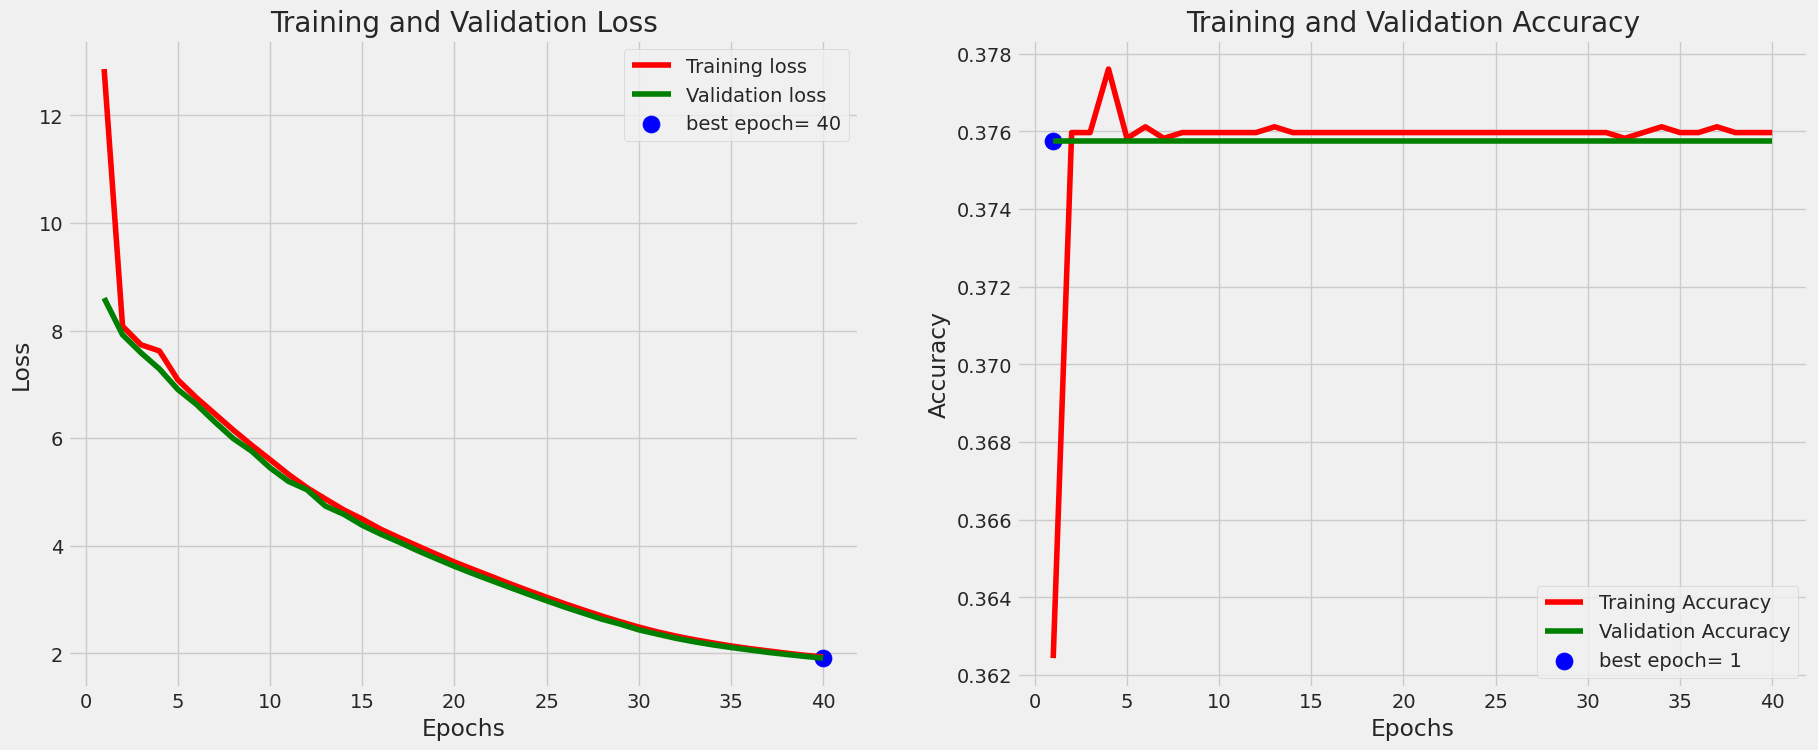

In [ ]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    plt.show()

tr_plot(history,0)

<a id="result"></a>
# <center>Make Predictions on the test set</a>
### Define a function which takes in a test generator and an integer test_steps
### and generates predictions on the test set including a confusion matric
### and a classification report

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step
file  /content/cauliflower_training/cali/Bacterial Soft Rot/N_456BacterialSoftRot_original_BSRot(35).jpg_6937b0b4-8791-485c-91c8-997e59c881ce.jpg  was an error
file  /content/cauliflower_training/cali/Bacterial Soft Rot/N_456BacterialSoftRot_original_BSRot(7).jpg_19164a5c-9fcb-4cc0-a408-9c80cc5a177a.jpg  was an error
file  /content/cauliflower_training/cali/Bacterial Soft Rot/Bacterial soft rot_0_6236.jpeg  was an error
file  /content/cauliflower_training/cali/Bacterial Soft Rot/N_456BacterialSoftRot_original_BSRot(63).jpg_dd0c5c62-788f-42c8-84cb-dcc2de2f11ae.jpg  was an error
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/N_456AlterneriaLeafSpot_original_ALS(77).jpg_bcd8dfbf-1f34-4247-82f0-f269c2a0c916.jpg  was an error
file  /content/cauliflower_training/cali/Downy Mildew/Downy Mildew_89.jpeg  was an error
file  /content/cauliflower_training/cali/Black Rot/Black Rot (771).png  was an error
file  /content/cauliflower_training/cal

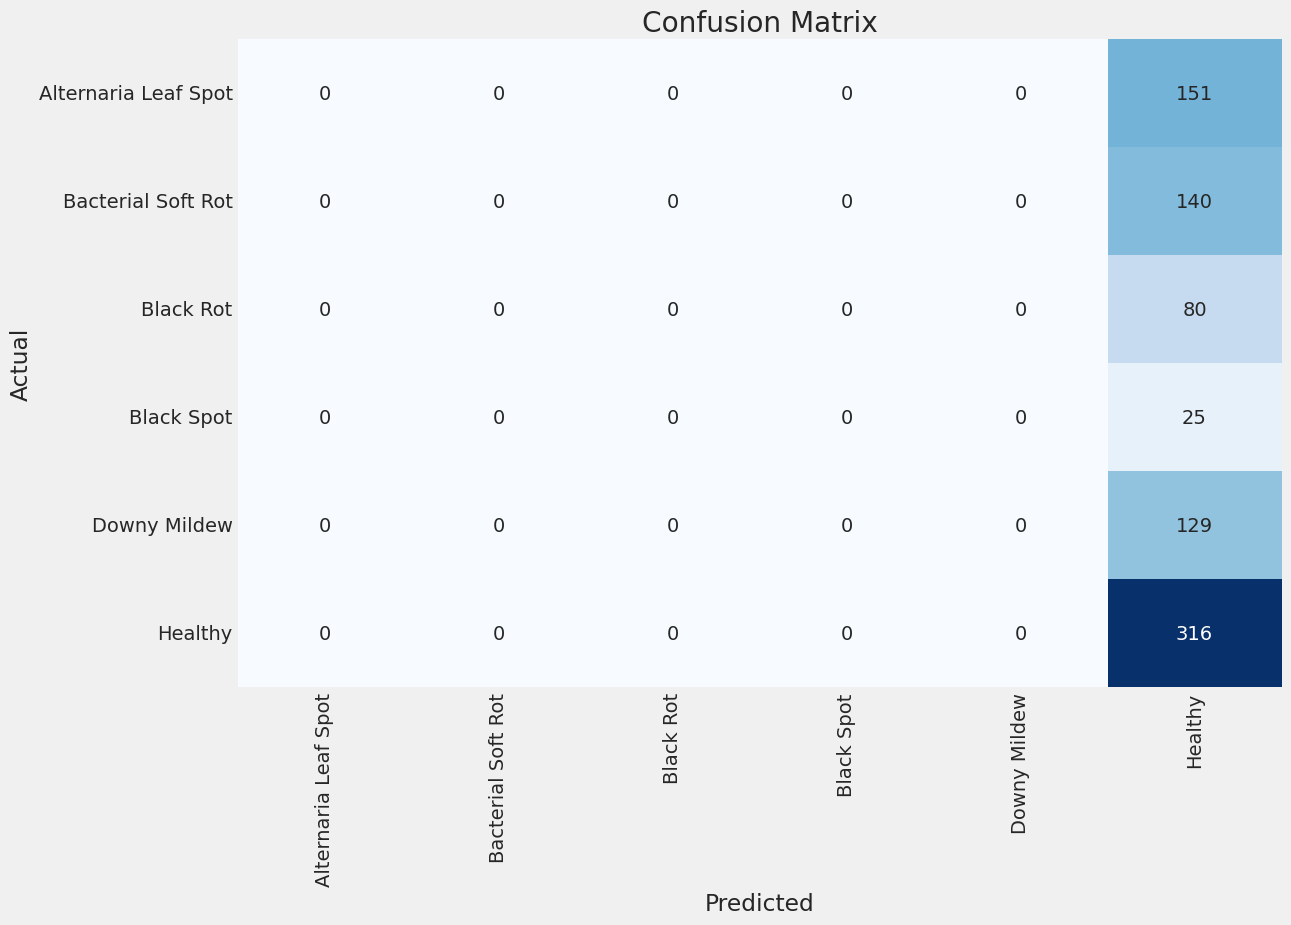

Classification Report:
----------------------
                       precision    recall  f1-score   support

Alternaria Leaf Spot     0.0000    0.0000    0.0000       151
  Bacterial Soft Rot     0.0000    0.0000    0.0000       140
           Black Rot     0.0000    0.0000    0.0000        80
          Black Spot     0.0000    0.0000    0.0000        25
        Downy Mildew     0.0000    0.0000    0.0000       129
             Healthy     0.3757    1.0000    0.5462       316

            accuracy                         0.3757       841
           macro avg     0.0626    0.1667    0.0910       841
        weighted avg     0.1412    0.3757    0.2052       841



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def predictor(test_gen, test_steps):
    y_pred= []
    y_true=test_gen.labels
    classes=list(test_gen.class_indices.keys())
    class_count=len(classes)
    errors=0
    preds=model.predict(test_gen, verbose=1)
    tests=len(preds)
    for i, p in enumerate(preds):
        pred_index=np.argmax(p)
        true_index=test_gen.labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            errors=errors + 1
            file=test_gen.filenames[i]
            print ('file ', file, ' was an error')
        y_pred.append(pred_index)

    acc=( 1-errors/tests) * 100
    print(f'there were {errors} errors in {tests} tests for an accuracy of {acc:6.2f}')
    ypred=np.array(y_pred)
    ytrue=np.array(y_true)
    if class_count <=30:
        cm = confusion_matrix(ytrue, ypred )
        # plot the confusion matrix
        plt.figure(figsize=(12, 8))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(class_count)+.5, classes, rotation=90)
        plt.yticks(np.arange(class_count)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes, digits= 4) # create classification report
    print("Classification Report:\n----------------------\n", clr)
    return errors, tests
errors, tests=predictor(test_gen, test_steps)

<a id="save"></a>
# <center>Save the model

In [ ]:
subject='nuts'
acc=str(( 1-errors/tests) * 100)
index=acc.rfind('.')
acc=acc[:index + 3]
save_id= subject + '_' + str(acc) + '.h5'
model_save_loc=os.path.join(working_dir, save_id)
model.save(model_save_loc)
print ('model was saved as ' , model_save_loc )


model was saved as  ./nuts_37.57.h5
